<table>
    <tr> 
    <th> 
        <table>
            <tr>                                                                                   
                 <th  style="font-size:150%;ftext-align:left;background-color:#053061;color:white;">Valeur</th>
                 <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Nom classe</th>
             </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">0</th>
                <th  style="font-size:150%;text-align:left">basophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">1</th>
                <th  style="font-size:150%;text-align:left;">eosinophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">2</th>
                <th  style="font-size:150%;text-align:left">erythroblast</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">3</th>
                <th  style="font-size:150%;text-align:left">immature</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">4</th>
                <th  style="font-size:150%;text-align:left;">lymphocyte</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">5</th>
                <th  style="font-size:150%;text-align:left;">monocyte</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">6</th>
                <th  style="font-size:150%;text-align:left;">neutrophil</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">7</th>
                <th  style="font-size:150%;text-align:left">platelet</th>
            </tr>            
        </table>
    </th>
    <th>     
        <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'>BloodMNIST<br> Standardized Biomedical Images</div>        
        <img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/bloodMNIST8.png" width="512">
    </th>
    </tr>
</table>   

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'><a href="https://github.com/MedMNIST/MedMNIST/tree/main">Veuillez vous référer à la page Github officielle pour plus de détails.</a></div>

>> **site du projet** : https://medmnist.com/

>> **site de données** : https://zenodo.org/records/10519652 


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Initialisation du document</div></b>

In [1]:
import os
# import json
# @param ["tensorflow", "jax", "torch"]
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['KERAS_BACKEND'] = 'jax'  
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ['TF_CPP_MIN_LOG_LEVEL']='5'

import tensorflow as tf
import keras
tf.get_logger().setLevel('ERROR')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Import libriries </div></b>

In [2]:
import numpy as np, pandas as pd, seaborn as sns, warnings, os, sys, time
from matplotlib import pyplot as plt

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
    
sns.set(font_scale=2)

print(f"""La version des librairies utilisées :

Tensorflow : {tf.__version__}\tCUDA {tf.test.is_built_with_cuda()}\tGPU {tf.test.is_built_with_gpu_support()}\tXLA {tf.test.is_built_with_xla()}
Keras      : {keras.version()}
Pandas     : {pd.__version__}
NumPy      : {np.__version__}""")

La version des librairies utilisées :

Tensorflow : 2.17.0	CUDA True	GPU True	XLA True
Keras      : 3.6.0
Pandas     : 2.2.2
NumPy      : 1.26.4


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Outils du document</div></b>

In [3]:
sys.path.append(os.path.abspath('../outils/'))

In [4]:
if 'configProjet' in sys.modules.keys():  del(sys.modules['configProjet'])
if 'configModele' in sys.modules.keys():  del(sys.modules['configModele'])

In [5]:
from configProjet import palette, initParametresProjet 
from configProjet import afficheHistoriqueEntrainement, afficheProbabilites, afficheMatriceConfusion, afficheDataset, afficheDistributionsPipe

In [6]:
from configModele import modelDictionnaire, initParametresExecution, getPipelineDataset
from configModele import creationCompilationModele, creationRappelsExecution, entrainementModele
from configModele import sauvegarderModel, sauvegardeHistorique, executeApprentissageChoixClassifieurs
from configModele import modelCNNSimple, modelPersonalise, modelPersonaliseInception

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Paramétrés de l’exécution et les flux de lecture des fichiers TFRecors</div></b>

In [ ]:
image_size,batch_size,epochs,dictLabels,nombreClasses,pipelineApprentissage,pipelineValidation = \
       initParametresExecution(image_size=(28, 28, 3),
                            batch_size = 32,
                            epochs=128,
                            repertoire='../donnees/BloodMNIST',
                            cycle_length=None,
                            deterministic=None,
                            repetition=8,
                            bufferAleatoire=1024)

In [8]:
print(f"""
  image_size    = {image_size}
  batch_size    = {batch_size}
  epochs        = {epochs}
  nombreClasses = {nombreClasses}
  dictLabels    = {dictLabels}
       """)


  image_size    = (28, 28, 3)
  batch_size    = 32
  epochs        = 128
  nombreClasses = 8
  dictLabels    = {0: 'basophil', 1: 'eosinophil', 2: 'erythroblast', 3: 'immature', 4: 'lymphocyte', 5: 'monocyte', 6: 'neutrophil', 7: 'platelet'}
       


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage données</div></b>

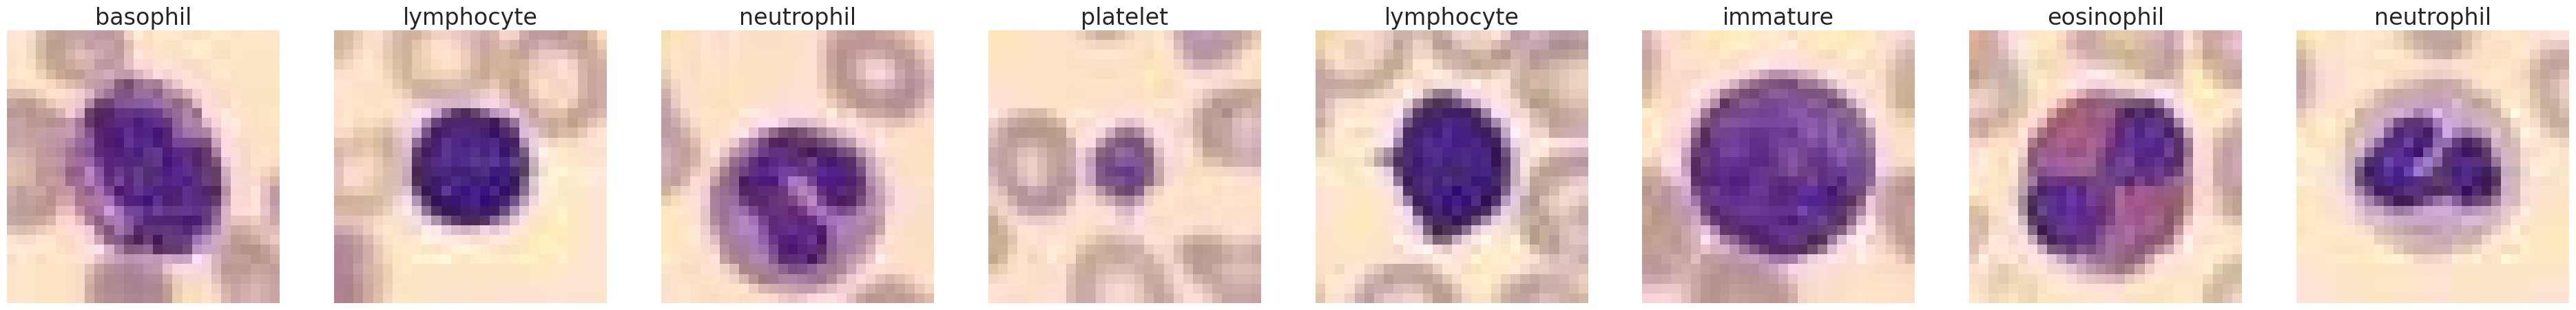

In [9]:
images, labels = next(iter(pipelineApprentissage))
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)

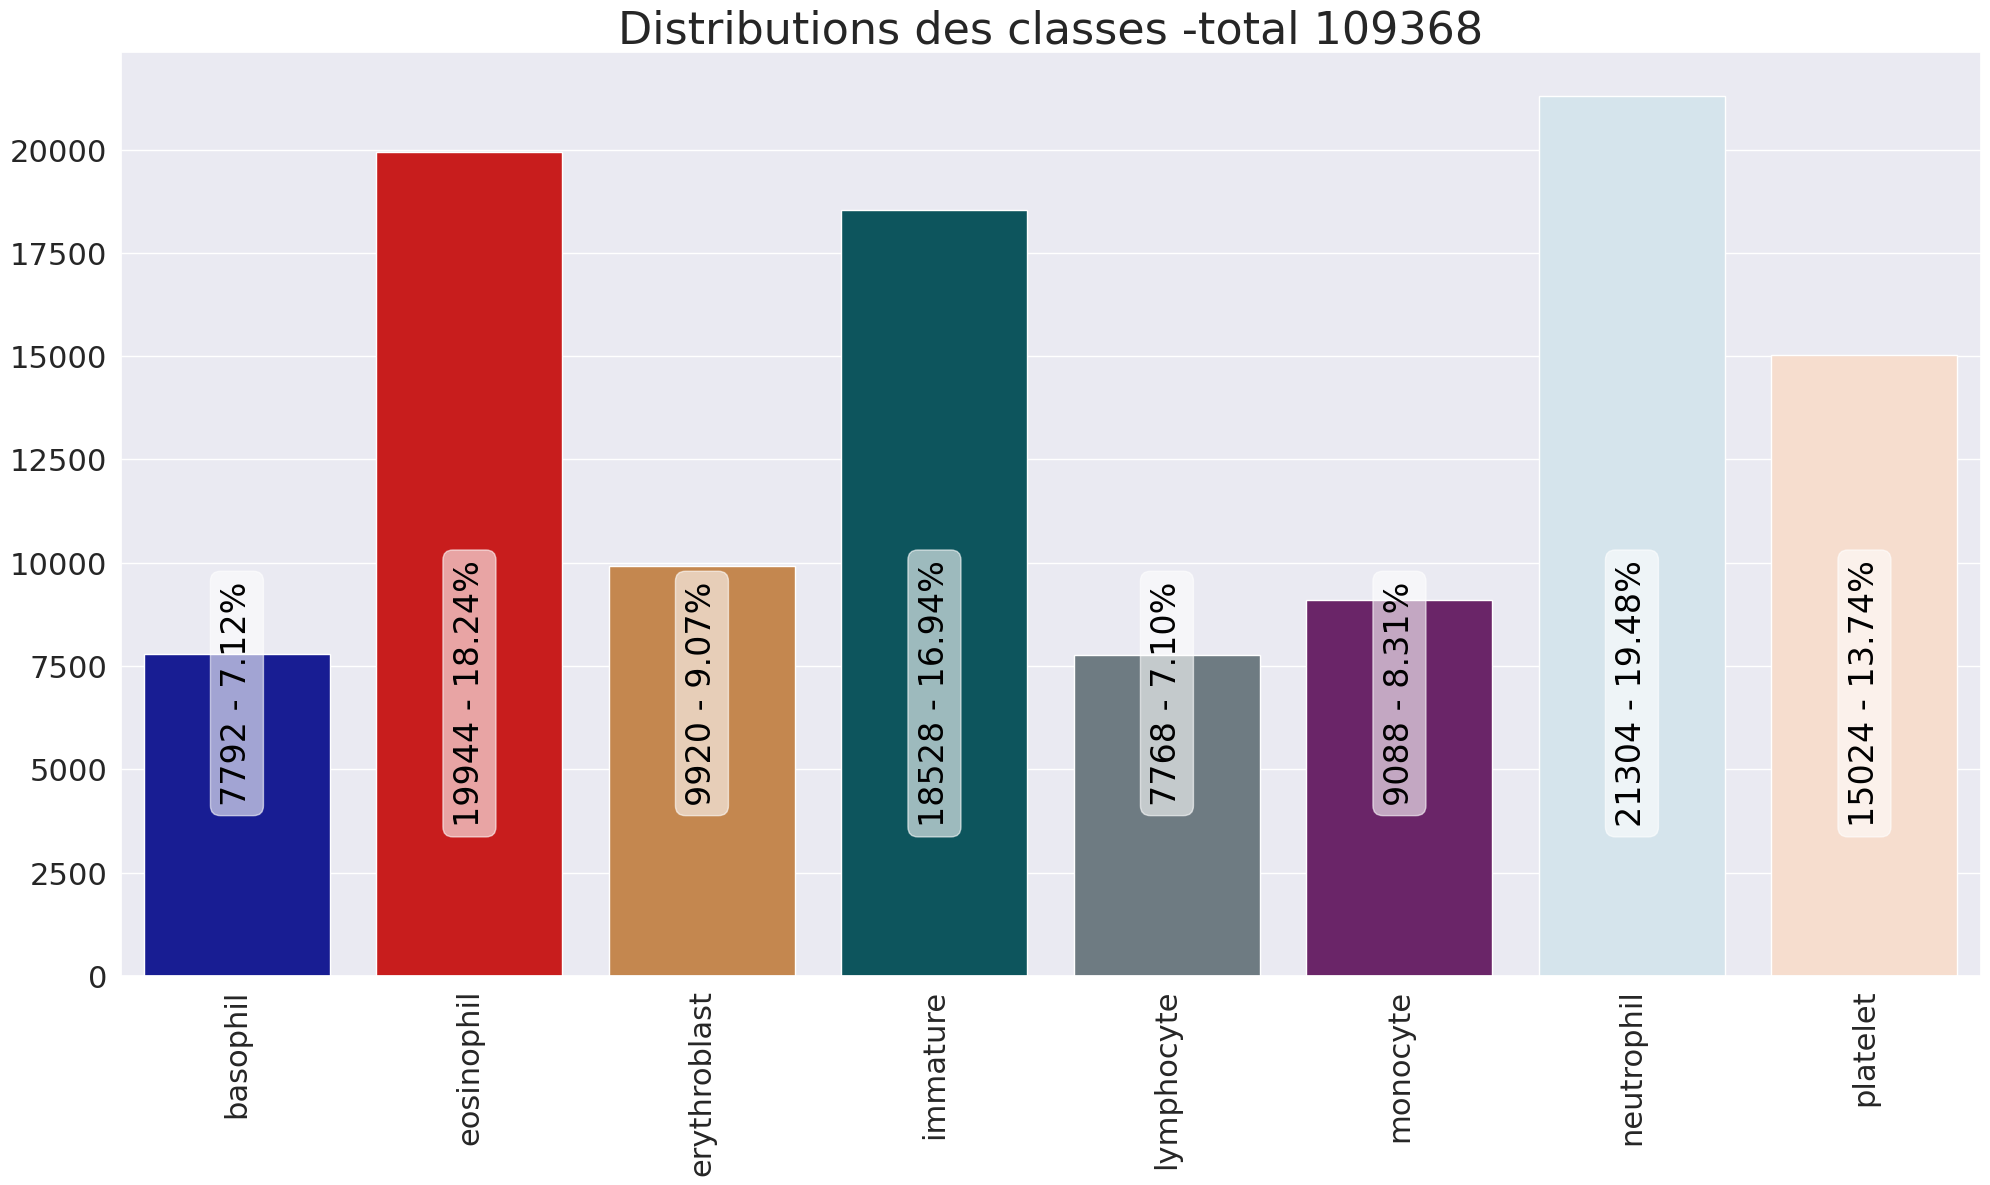

In [10]:
afficheDistributionsPipe(pipelineApprentissage, dictLabels, palette, repertoireEnregistrement=None)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Choix du modèle</div></b>

In [11]:
nomModel = 'CNN-PersonaliseMNIST'

In [12]:
repertoireEnregistrement,repertoireSauvegardes,repertoireModelCKP,repertoireModelSauvegarde,repertoireModelLogs = \
            initParametresProjet(nomProjet=f"2-bloodMNIST-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}",repertoireProjet='../ResultatsExecutions')

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Création et compilation d'un modèle</div></b>

## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Conception du modèle</div></b>


<table>
    <tr> 
        <th>                                                                                   
            <a href="https://arxiv.org/pdf/1602.07360"><img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/squeezeNet.png" width="512"></a>
        </th>
        <th>                                                                                   
            <a href="https://arxiv.org/abs/1610.02357"><img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/xception.png" width="512"></a>
        </th>
        <th>                                                                                   
            <a href="https://arxiv.org/abs/1512.03385"><img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/residualBlock.png" width="512"></a>
        </th>
    </tr>
</table>


``̀

    def blockTraitement(x, filtres):
        y  = keras.layers.Conv2D(filters=filtres, kernel_size=1, padding='same')(x)
        y  = keras.layers.BatchNormalization(scale=False)(y)
        y = keras.layers.Activation(activation)(y)
        
        y1 = keras.layers.Conv2D(filters=filtres, kernel_size=1, padding='same')(y)
        y1 = keras.layers.BatchNormalization(scale=False)(y1)
        y1 = keras.layers.Activation(activation)(y1)
        
        y3 = keras.layers.Conv2D(filters=filtres, kernel_size=3, padding='same')(y)
        y3 = keras.layers.BatchNormalization(scale=False)(y3)
        y3 = keras.layers.Activation(activation)(y3)
    
        z = keras.layers.SeparableConv2D(filtres, 3, padding="same")(x)
        z = keras.layers.BatchNormalization(scale=False)(z)
        z = keras.layers.Activation(activation)(z)
        z = keras.layers.Conv2D(filters=filtres, kernel_size=1, padding='same')(z)
        z = keras.layers.BatchNormalization(scale=False)(z)
        z = keras.layers.Activation(activation)(z) 

        return keras.layers.concatenate([y1, y3, z])


    for size in listeFiltres[1:]:
        x = blockTraitement(x, size)    
        x = keras.layers.Conv2D(size, 3, strides=2, padding="same")(x)
        
        residual = keras.layers.Conv2D(size, 1, strides=2, padding="same")(previous_block_activation)
        
        x = keras.layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual
        
``̀

In [13]:
def modelPersonalise(image_size, nombreClasses, listeFiltres=[128,128,256,512], dropout=0.5, activation=keras.ops.gelu, preprocessData=None):
    
    def blockTraitement(x, filtres):
        y  = keras.layers.Conv2D(filters=filtres, kernel_size=1, padding='same')(x)
        y  = keras.layers.BatchNormalization(scale=False)(y)
        y = keras.layers.Activation(activation)(y)
        
        y1 = keras.layers.Conv2D(filters=filtres, kernel_size=1, padding='same')(y)
        y1 = keras.layers.BatchNormalization(scale=False)(y1)
        y1 = keras.layers.Activation(activation)(y1)
        
        y3 = keras.layers.Conv2D(filters=filtres, kernel_size=3, padding='same')(y)
        y3 = keras.layers.BatchNormalization(scale=False)(y3)
        y3 = keras.layers.Activation(activation)(y3)
    
        z = keras.layers.SeparableConv2D(filtres, 3, padding="same")(x)
        z = keras.layers.BatchNormalization(scale=False)(z)
        z = keras.layers.Activation(activation)(z)
        z = keras.layers.Conv2D(filters=filtres, kernel_size=1, padding='same')(z)
        z = keras.layers.BatchNormalization(scale=False)(z)
        z = keras.layers.Activation(activation)(z) 

        return keras.layers.concatenate([y1, y3, z])
            

    inputs = keras.Input(shape=image_size)
    
    x = preprocessData(inputs)
    
    x = keras.layers.Conv2D(listeFiltres[0], 3, strides=1, padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)
    previous_block_activation = x  # Set aside residual
    
    for size in listeFiltres[1:]:
        x = blockTraitement(x, size)    
        x = keras.layers.Conv2D(size, 3, strides=2, padding="same")(x)
        
        residual = keras.layers.Conv2D(size, 1, strides=2, padding="same")(previous_block_activation)
        
        x = keras.layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual
    
    x = keras.layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)
    
    x = keras.layers.GlobalAveragePooling2D()(x)
    
    x = keras.layers.Dropout(dropout)(x)
    outputs = keras.layers.Dense(nombreClasses, activation="softmax")(x)
    
    return keras.Model(inputs, outputs, name='modelPersonalise')

In [14]:
preprocessData = tf.keras.Sequential([
            keras.layers.RandomRotation(factor=(-0.3, 0.3)),
            keras.layers.RandomFlip(mode='horizontal_and_vertical'),
            keras.layers.Rescaling(1.0 / 255),
        ])

model = modelPersonalise(image_size=image_size, 
                         nombreClasses=nombreClasses, 
                         listeFiltres=[64,64,128,256],
                         dropout=0.5 ,
                         activation=keras.ops.gelu,
                         preprocessData=preprocessData)

In [15]:
model.compile(
        optimizer=keras.optimizers.AdamW(1e-03), 
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
    )

In [16]:
model.summary()

Model: "modelPersonalise"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 28, 28, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │      1,792 │ sequential[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        192 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      4,160 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 28, 28,    │      4,736 │ activation[0][0]  │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        192 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │      4,160 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │      4,160 │ activation_4[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        192 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        192 │ conv2d_4[0][0]  

 Total params: 3,694,664 (14.09 MB)

 Trainable params: 3,688,008 (14.07 MB)

 Non-trainable params: 6,656 (26.00 KB)

In [17]:
keras.utils.plot_model(model, show_shapes=True)

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Rappels d’exécution (callbacks)</div></b>

In [16]:
callbacks = creationRappelsExecution(repertoireModelSauvegarde,
                                     repertoireModelCKP,
                                     repertoireModelLogs,
                                     patienceArretPrecoce=6,
                                     initial_lrate=1e-03,
                                     max_lrate=1e-03,
                                     min_lrate=1e-05,
                                     epochs_runup_lrate=0,
                                     epochs_sustain_lrate=0,
                                     drop_lrate=0.98)

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Evolution du taux d'apprentissage</div></b>

In [17]:
def evolutionTauxApprentissage(epoch,
                               initial_lrate=1e-03,
                               max_lrate=1e-03,
                               min_lrate=1e-05,
                               epochs_runup_lrate=0,
                               epochs_sustain_lrate=0,
                               drop_lrate=0.98):
    # epochs_drop = epochs * 0.1
    if epoch < epochs_runup_lrate:
        lrate = (max_lrate - initial_lrate) / epochs_runup_lrate * epoch + initial_lrate
    elif epoch < epochs_runup_lrate + epochs_sustain_lrate:
        lrate = max_lrate
    else:
        lrate = (max_lrate - min_lrate) * drop_lrate**(epoch - epochs_runup_lrate - epochs_sustain_lrate) + min_lrate
    return lrate

L'évolution du taux d'apprentissage : du 0.001 à 8.61e-05


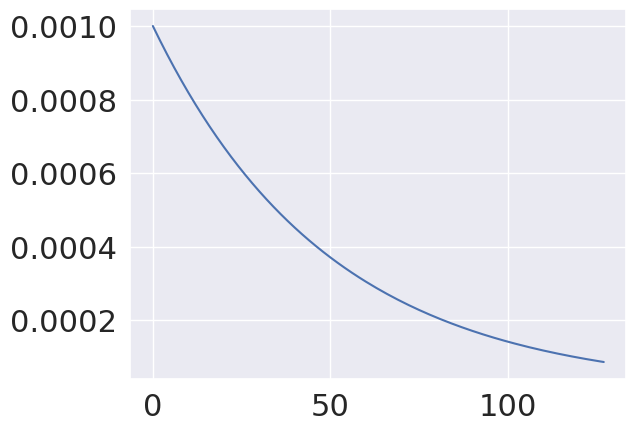

In [18]:
rng = [i for i in range(epochs)]
y = [evolutionTauxApprentissage(x) for x in rng]
plt.plot(rng, y)

print(f"L'évolution du taux d'apprentissage : du {y[0]:.3g} à {min(y):.3g}")

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Entrainement du modèle</div></b>


In [19]:
historiqueApprentissage, model = entrainementModele( model, 
                                                     pipelineApprentissage,
                                                     pipelineValidation, 
                                                     epochs, 
                                                     batch_size,
                                                     callbacks,
                                                     2, #verbose=2, 
                                                     repertoireModelSauvegarde)

Epoch 1/128

Epoch 1: val_loss improved from inf to 0.38550, saving model to ../ResultatsExecutions/2-bloodMNIST-CNN-PersonaliseMNIST-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
3418/3418 - 850s - 249ms/step - accuracy: 0.8997 - loss: 0.2788 - val_accuracy: 0.8793 - val_loss: 0.3855 - learning_rate: 0.0010
Epoch 2/128

Epoch 2: val_loss did not improve from 0.38550
3418/3418 - 822s - 240ms/step - accuracy: 0.9433 - loss: 0.1572 - val_accuracy: 0.8375 - val_loss: 0.6721 - learning_rate: 9.8020e-04
Epoch 3/128

Epoch 3: val_loss did not improve from 0.38550
3418/3418 - 825s - 241ms/step - accuracy: 0.9564 - loss: 0.1238 - val_accuracy: 0.8369 - val_loss: 0.5791 - learning_rate: 9.6080e-04
Epoch 4/128

Epoch 4: val_loss improved from 0.38550 to 0.26702, saving model to ../ResultatsExecutions/2-bloodMNIST-CNN-PersonaliseMNIST-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
3418/3418 - 834s - 244ms/step - accuracy: 0.9639 - loss: 0.1025 - val_accuracy: 0.9199 -

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage historique de l'apprentissage </div></b>

In [20]:
historique = sauvegardeHistorique(historiqueApprentissage,
                                  repertoireSauvegardes,
                                  nomSauvegarde=f'historique-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

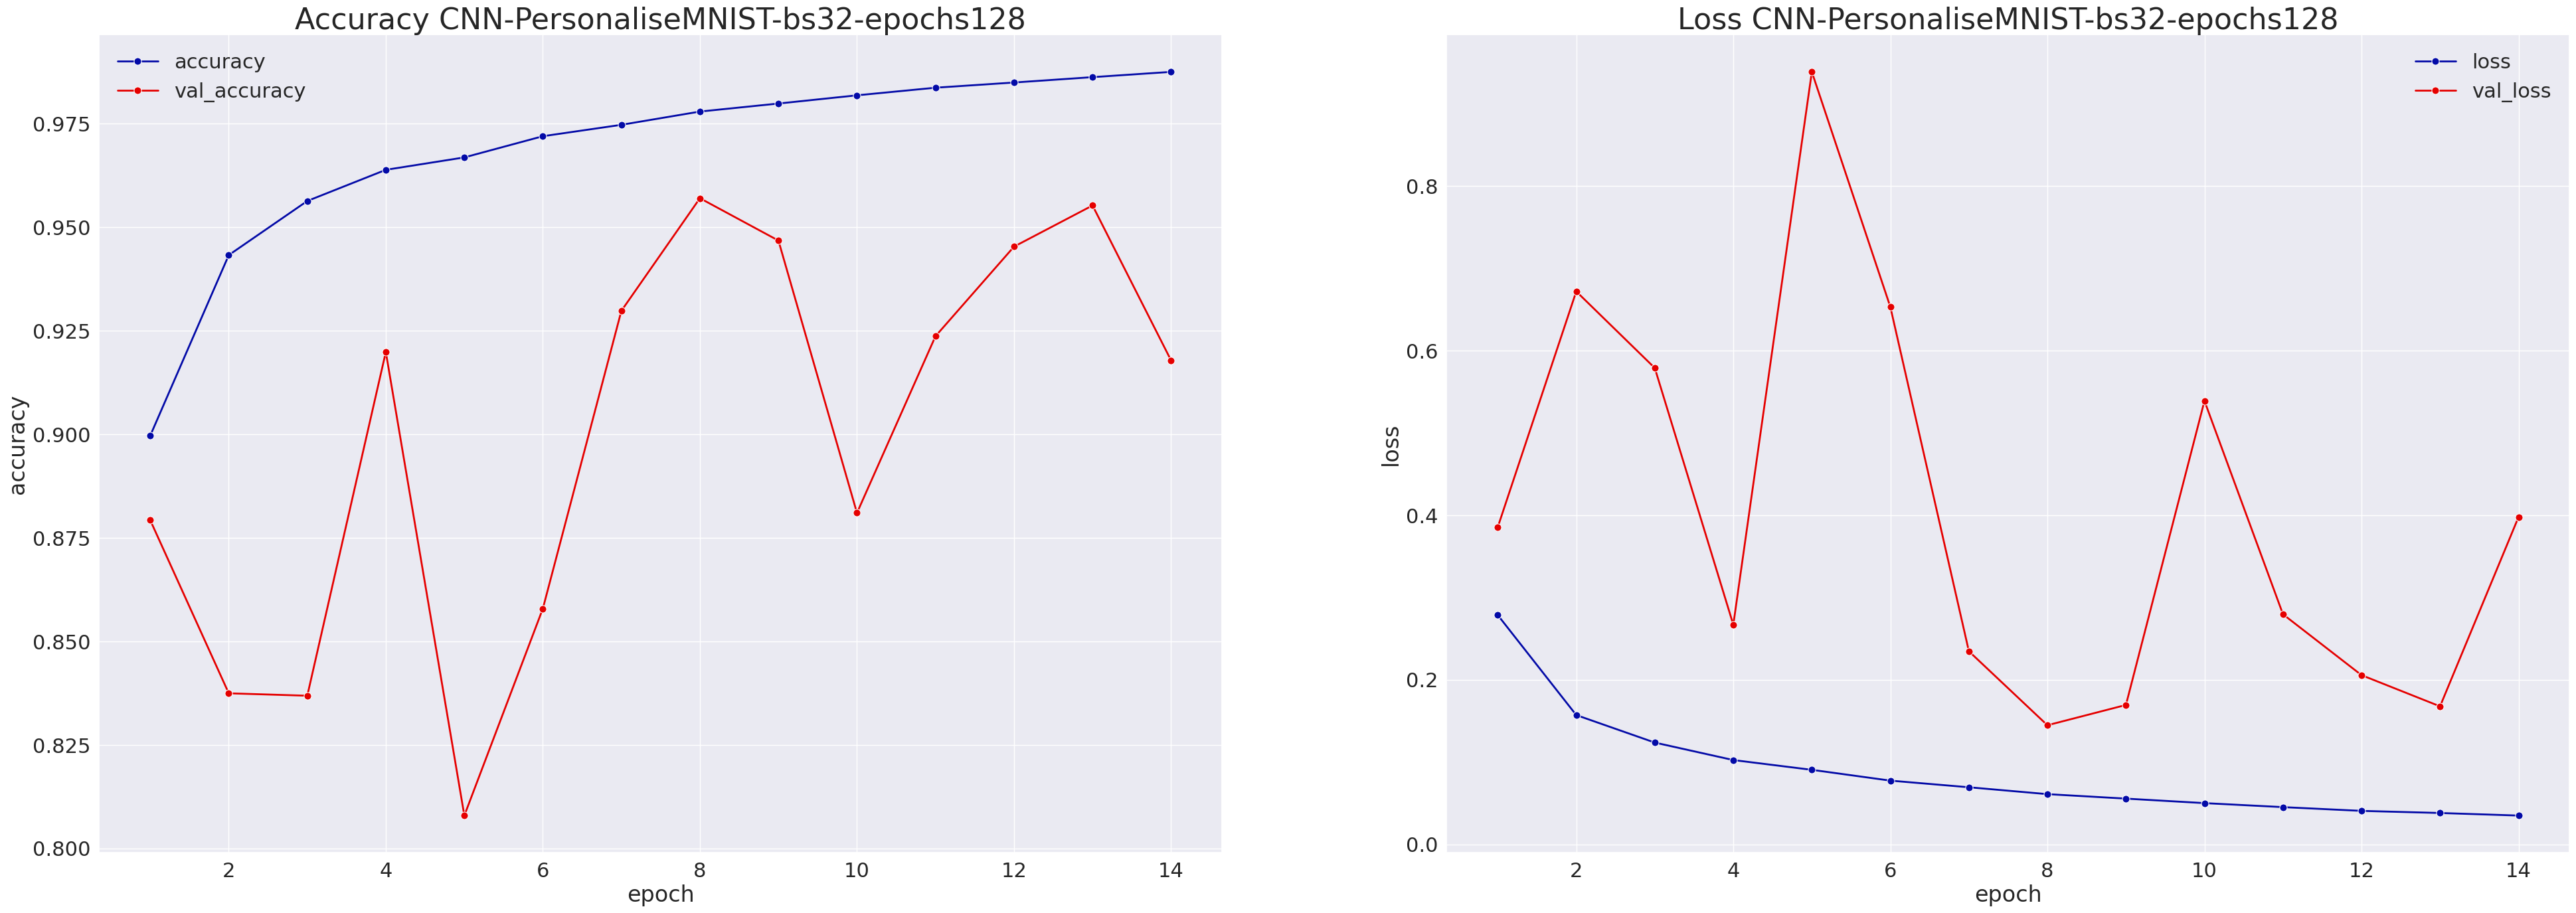

In [21]:
afficheHistoriqueEntrainement(historique, palette, f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}', repertoireEnregistrement)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Sauvegarde du modèle </div></b>

In [22]:
model.save(os.path.join(repertoireModelSauvegarde,f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.keras'))

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Inférence</div></b>

In [23]:
for i, (img,lab) in enumerate(pipelineValidation): 
    images, labels = img if i==0 else tf.concat([images,img], 0), lab if i==0 else tf.concat([labels,lab], 0)

In [24]:
probabilities = model.predict(images, verbose=0)
predictions = np.argmax(probabilities, axis=-1)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Probabilités pour les 8 premiers prédictions </div></b>

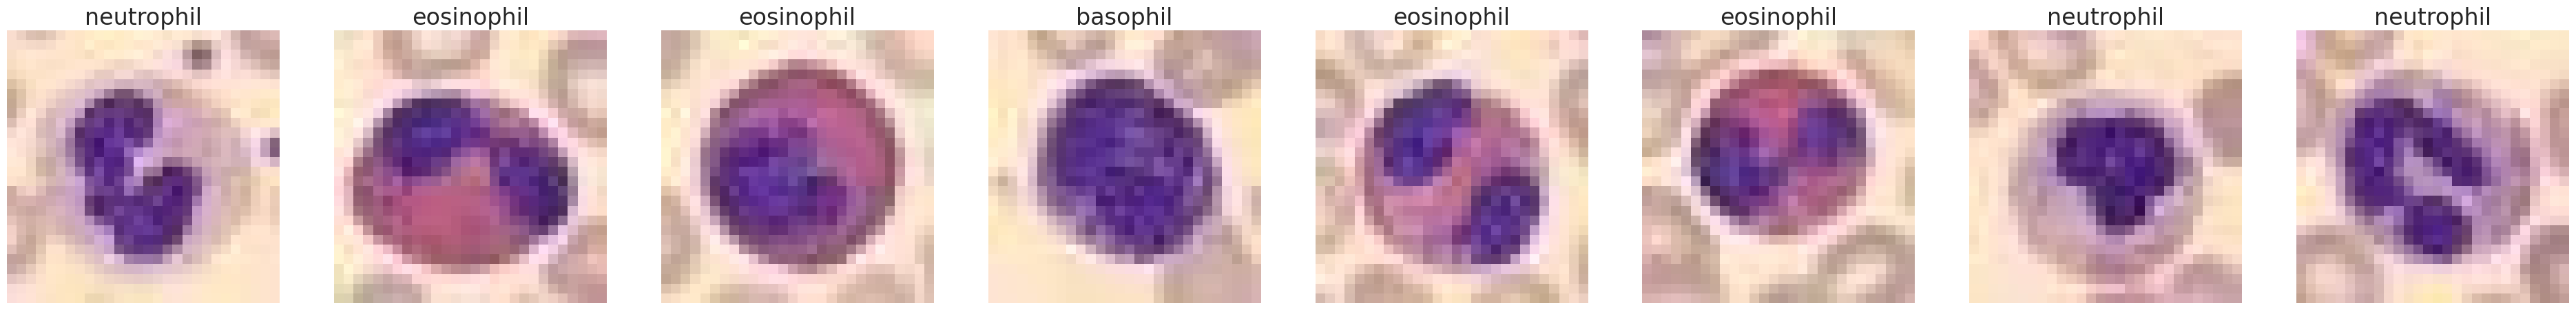

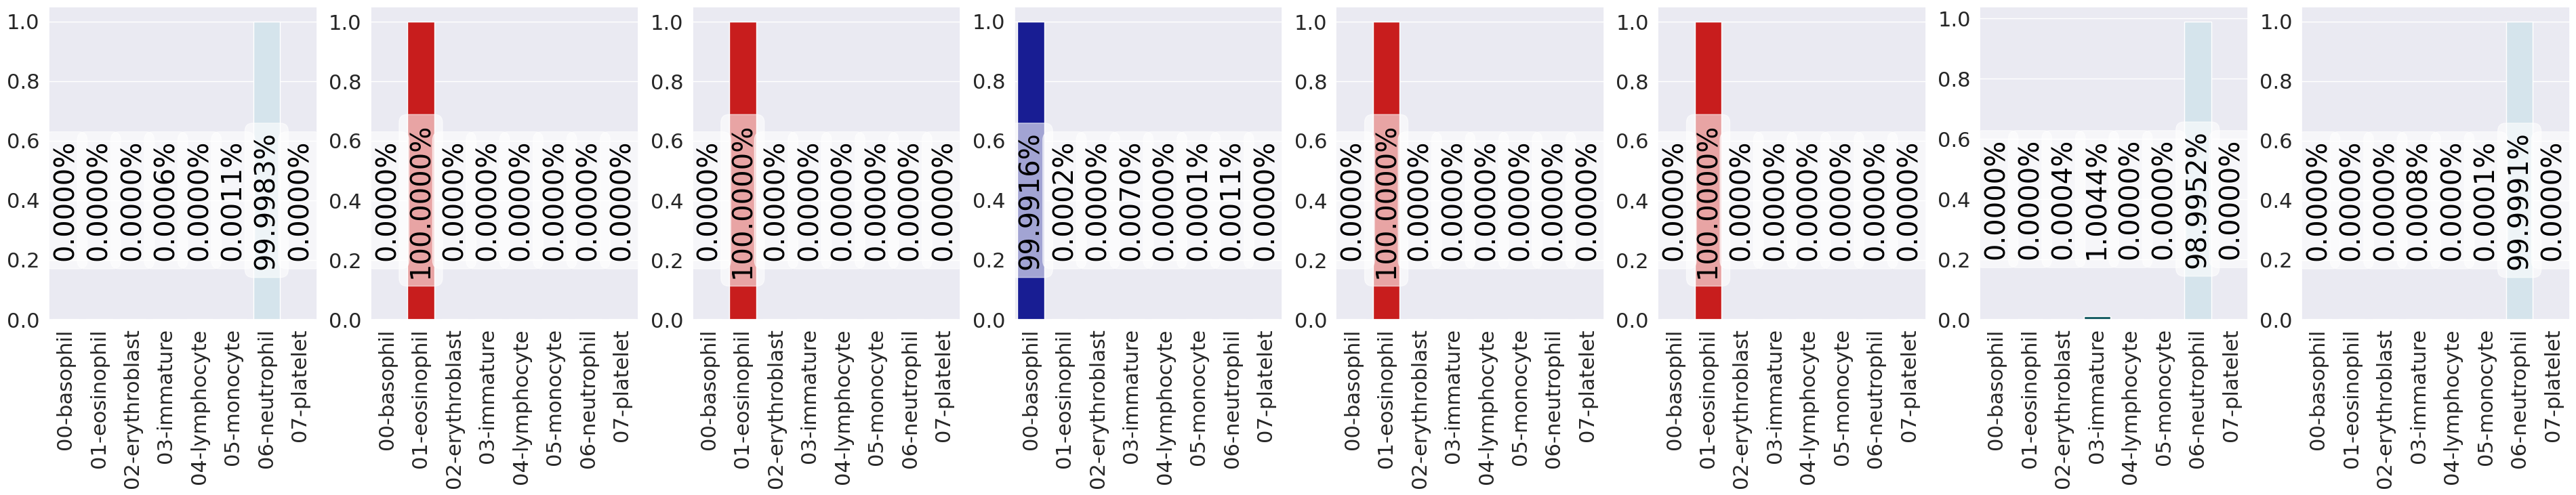

In [25]:
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)
fig, ax = plt.subplots(nrows=1, ncols=nombresImages,figsize=(6*nombresImages,6));
for i in range(nombresImages):
    afficheProbabilites(probabilities,ind=i,ax=ax[i], dictLabels=dictLabels)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Matrice de Confusion </div></b>

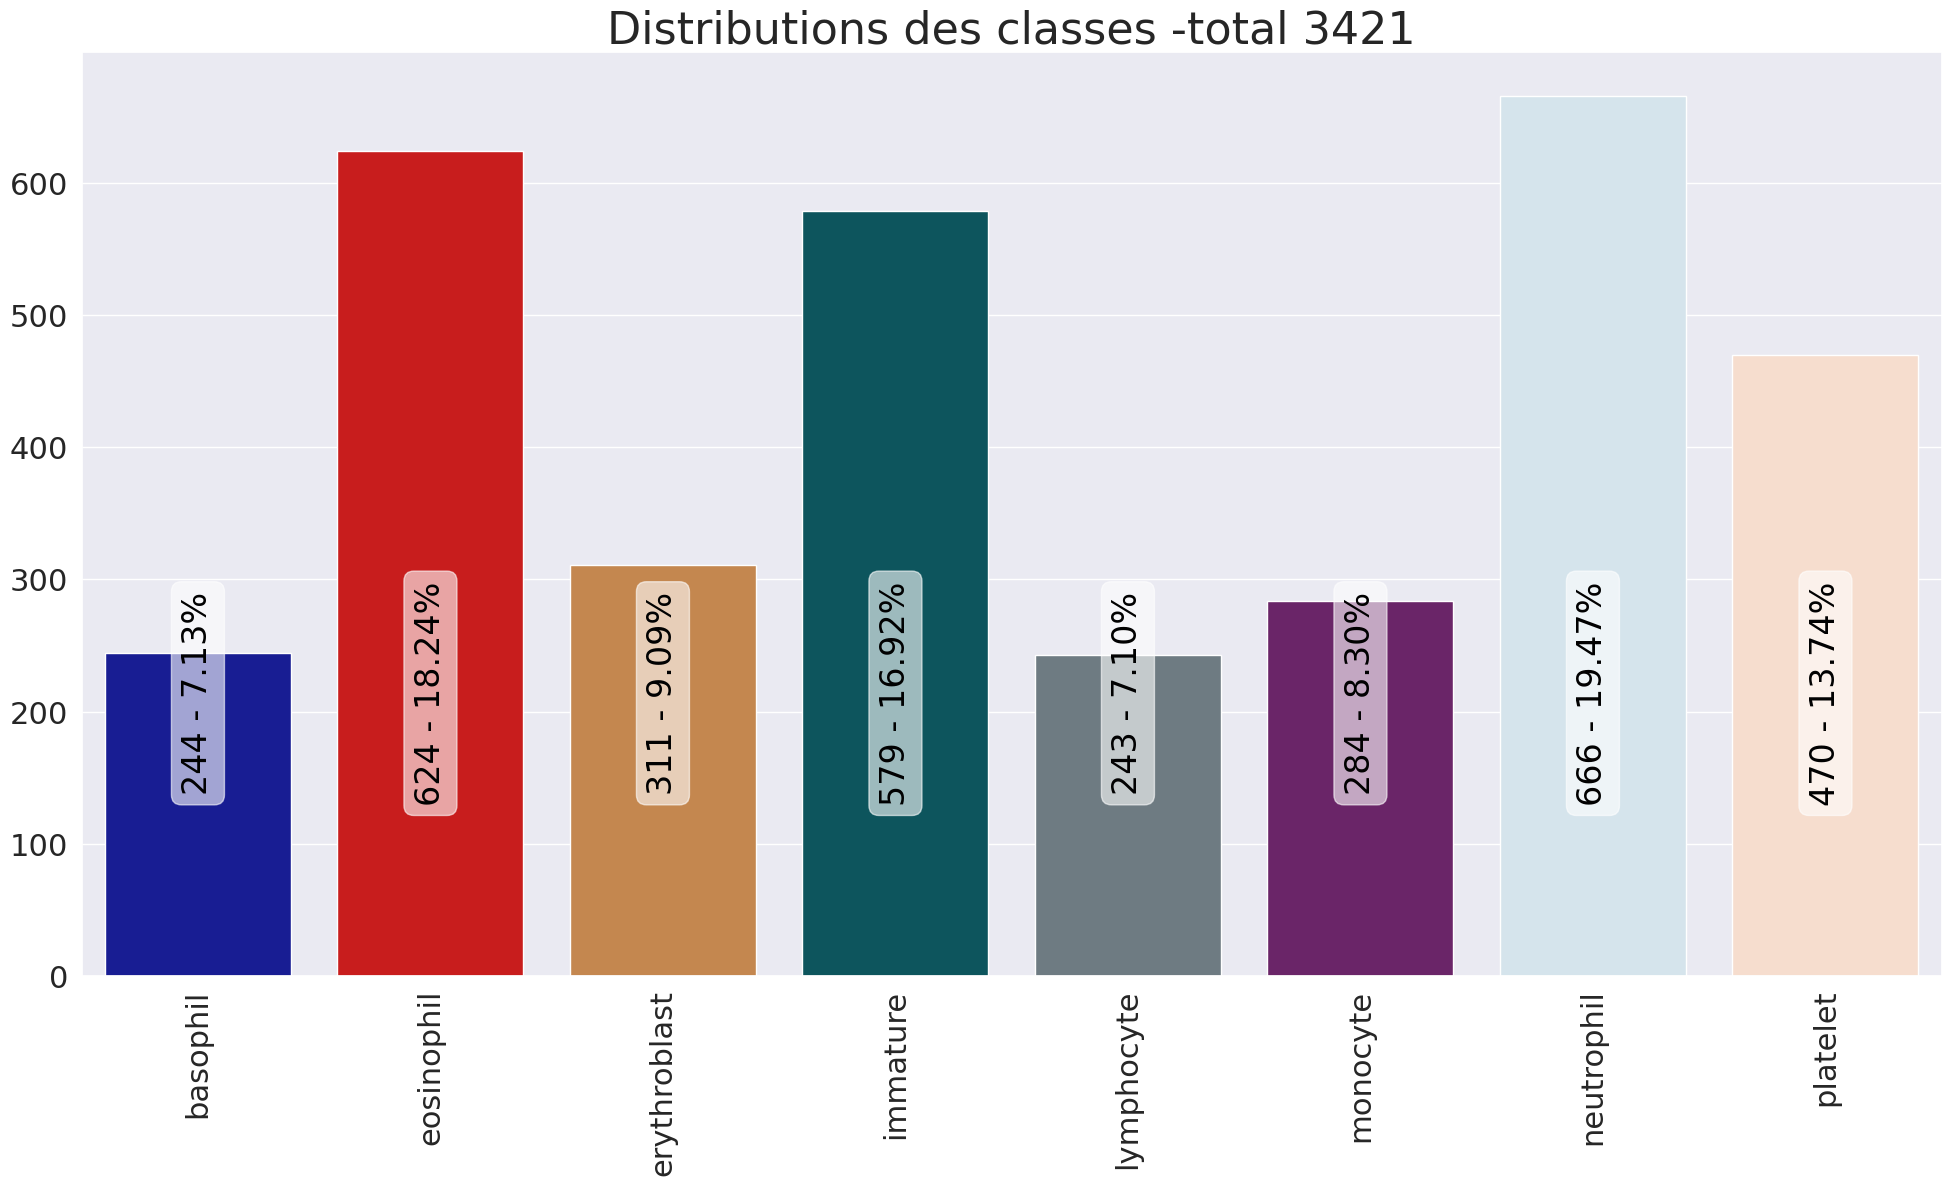

In [26]:
afficheDistributionsPipe(pipelineValidation, dictLabels, palette, repertoireEnregistrement=None)

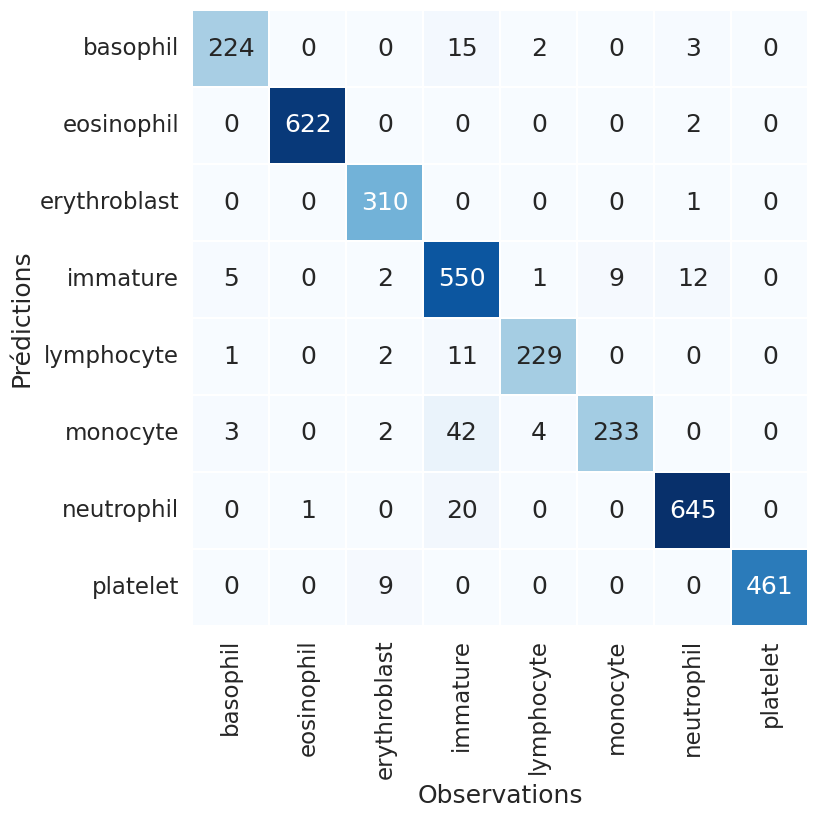

In [27]:
afficheMatriceConfusion(observations=labels,predictions=predictions,dictLabels=dictLabels, repertoireEnregistrement=repertoireEnregistrement,
                        nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Résultats de l’apprentissage</div></b>

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Area under the ROC curve : 0.9980	--	Exécution  :4.47s


,Classe,aucROC,avgPrecRec,f1,f2,f05,accuracy,precision,sensibilite,vrais_positifs,vrais_negatifs,faux_positifs,faux_negatifs,total_positifs,essai
0,global,0.997975,0.990890,0.957042,0.956816,0.957942,0.957030,0.958932,0.957030,3274,23800,147,147,3421,CNN-PersonaliseMNIST-bs32-epochs128
1,basophil,0.998010,0.982733,0.939203,0.926385,0.952381,0.991523,0.961373,0.918033,224,3168,9,20,244,CNN-PersonaliseMNIST-bs32-epochs128
2,eosinophil,0.999791,0.998114,0.997594,0.997114,0.998074,0.999123,0.998395,0.996795,622,2796,1,2,624,CNN-PersonaliseMNIST-bs32-epochs128
3,erythroblast,0.999853,0.998594,0.974843,0.987890,0.962135,0.995323,0.953846,0.996785,310,3095,15,1,311,CNN-PersonaliseMNIST-bs32-epochs128
4,immature,0.994255,0.972267,0.903862,0.930941,0.878314,0.965799,0.862069,0.949914,550,2754,88,29,579,CNN-PersonaliseMNIST-bs32-epochs128
5,lymphocyte,0.999458,0.992125,0.956159,0.947848,0.964617,0.993861,0.970339,0.942387,229,3171,7,14,243,CNN-PersonaliseMNIST-bs32-epochs128
6,monocyte,0.994610,0.963470,0.885932,0.845428,0.930511,0.982461,0.962810,0.820423,233,3128,9,51,284,CNN-PersonaliseMNIST-bs32-epochs128
7,neutrophil,0.997824,0.996184,0.970655,0.969342,0.971971,0.988600,0.972851,0.968468,645,2737,18,21,666,CNN-PersonaliseMNIST-bs32-epochs128
8,platelet,1.000000,1.000000,0.990333,0.984622,0.996111,0.997369,1.000000,0.980851,461,2951,0,9,470,CNN-PersonaliseMNIST-bs32-epochs128


<Figure size 1800x1800 with 0 Axes>

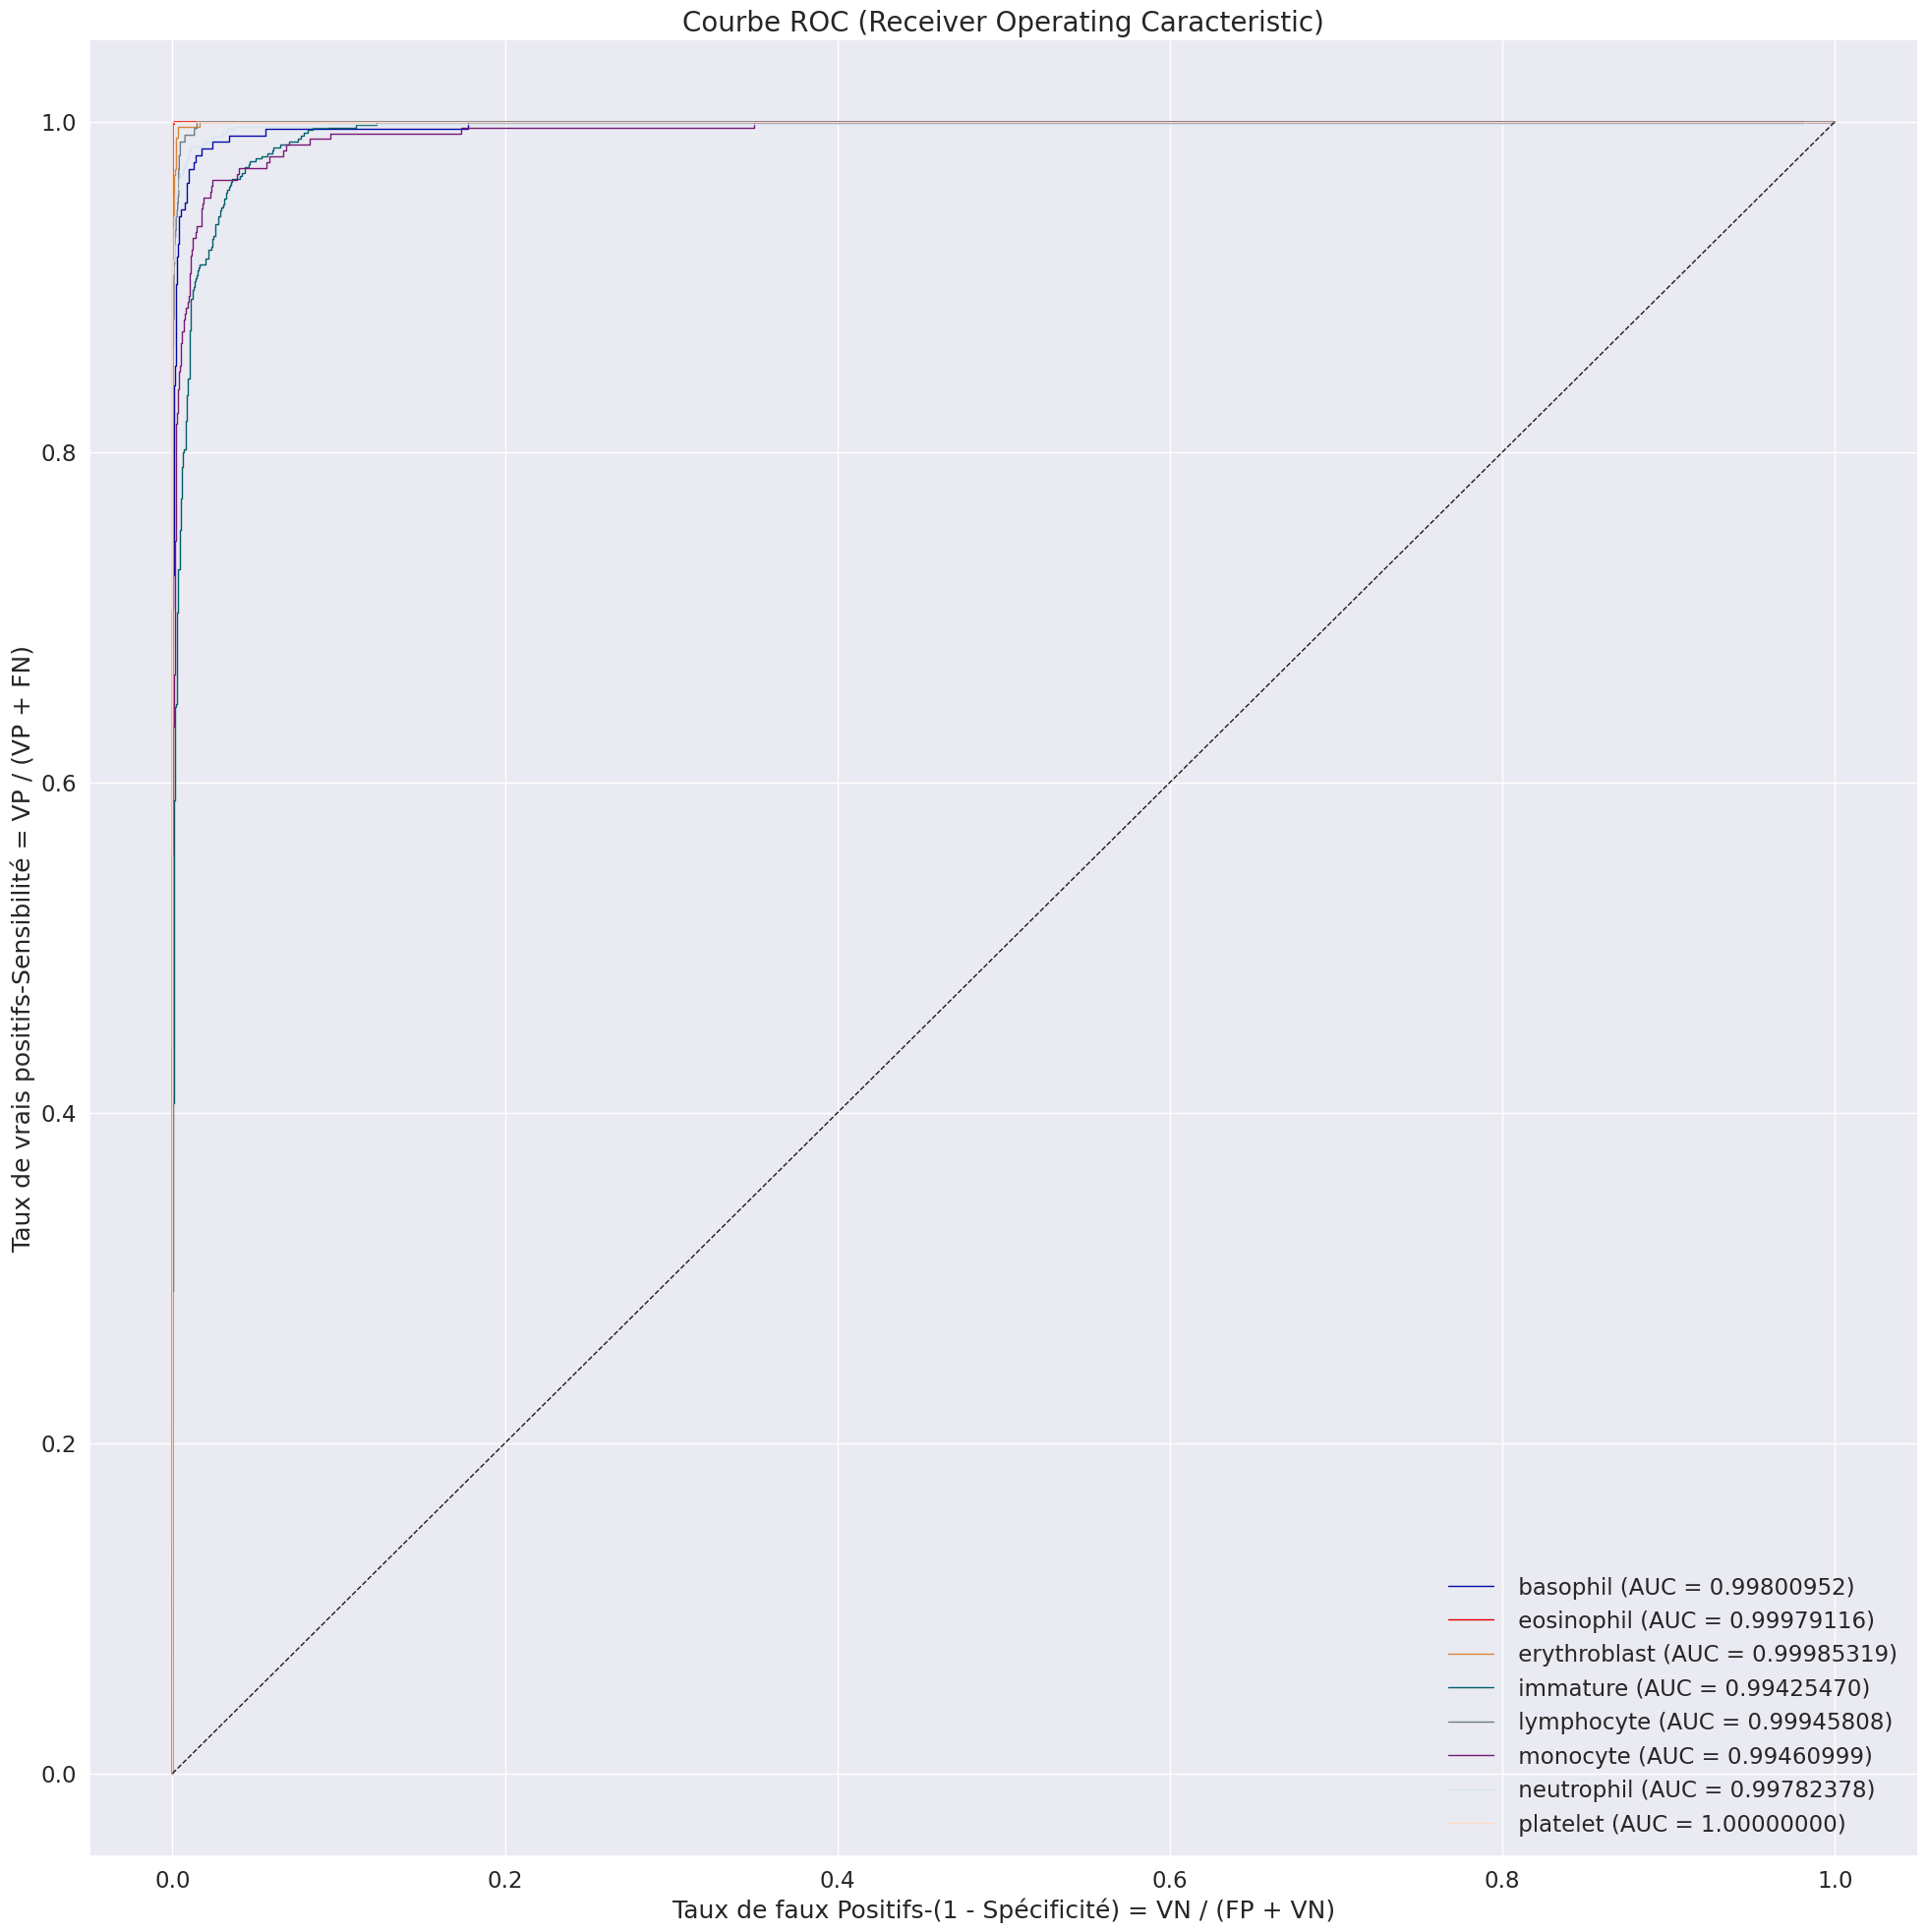

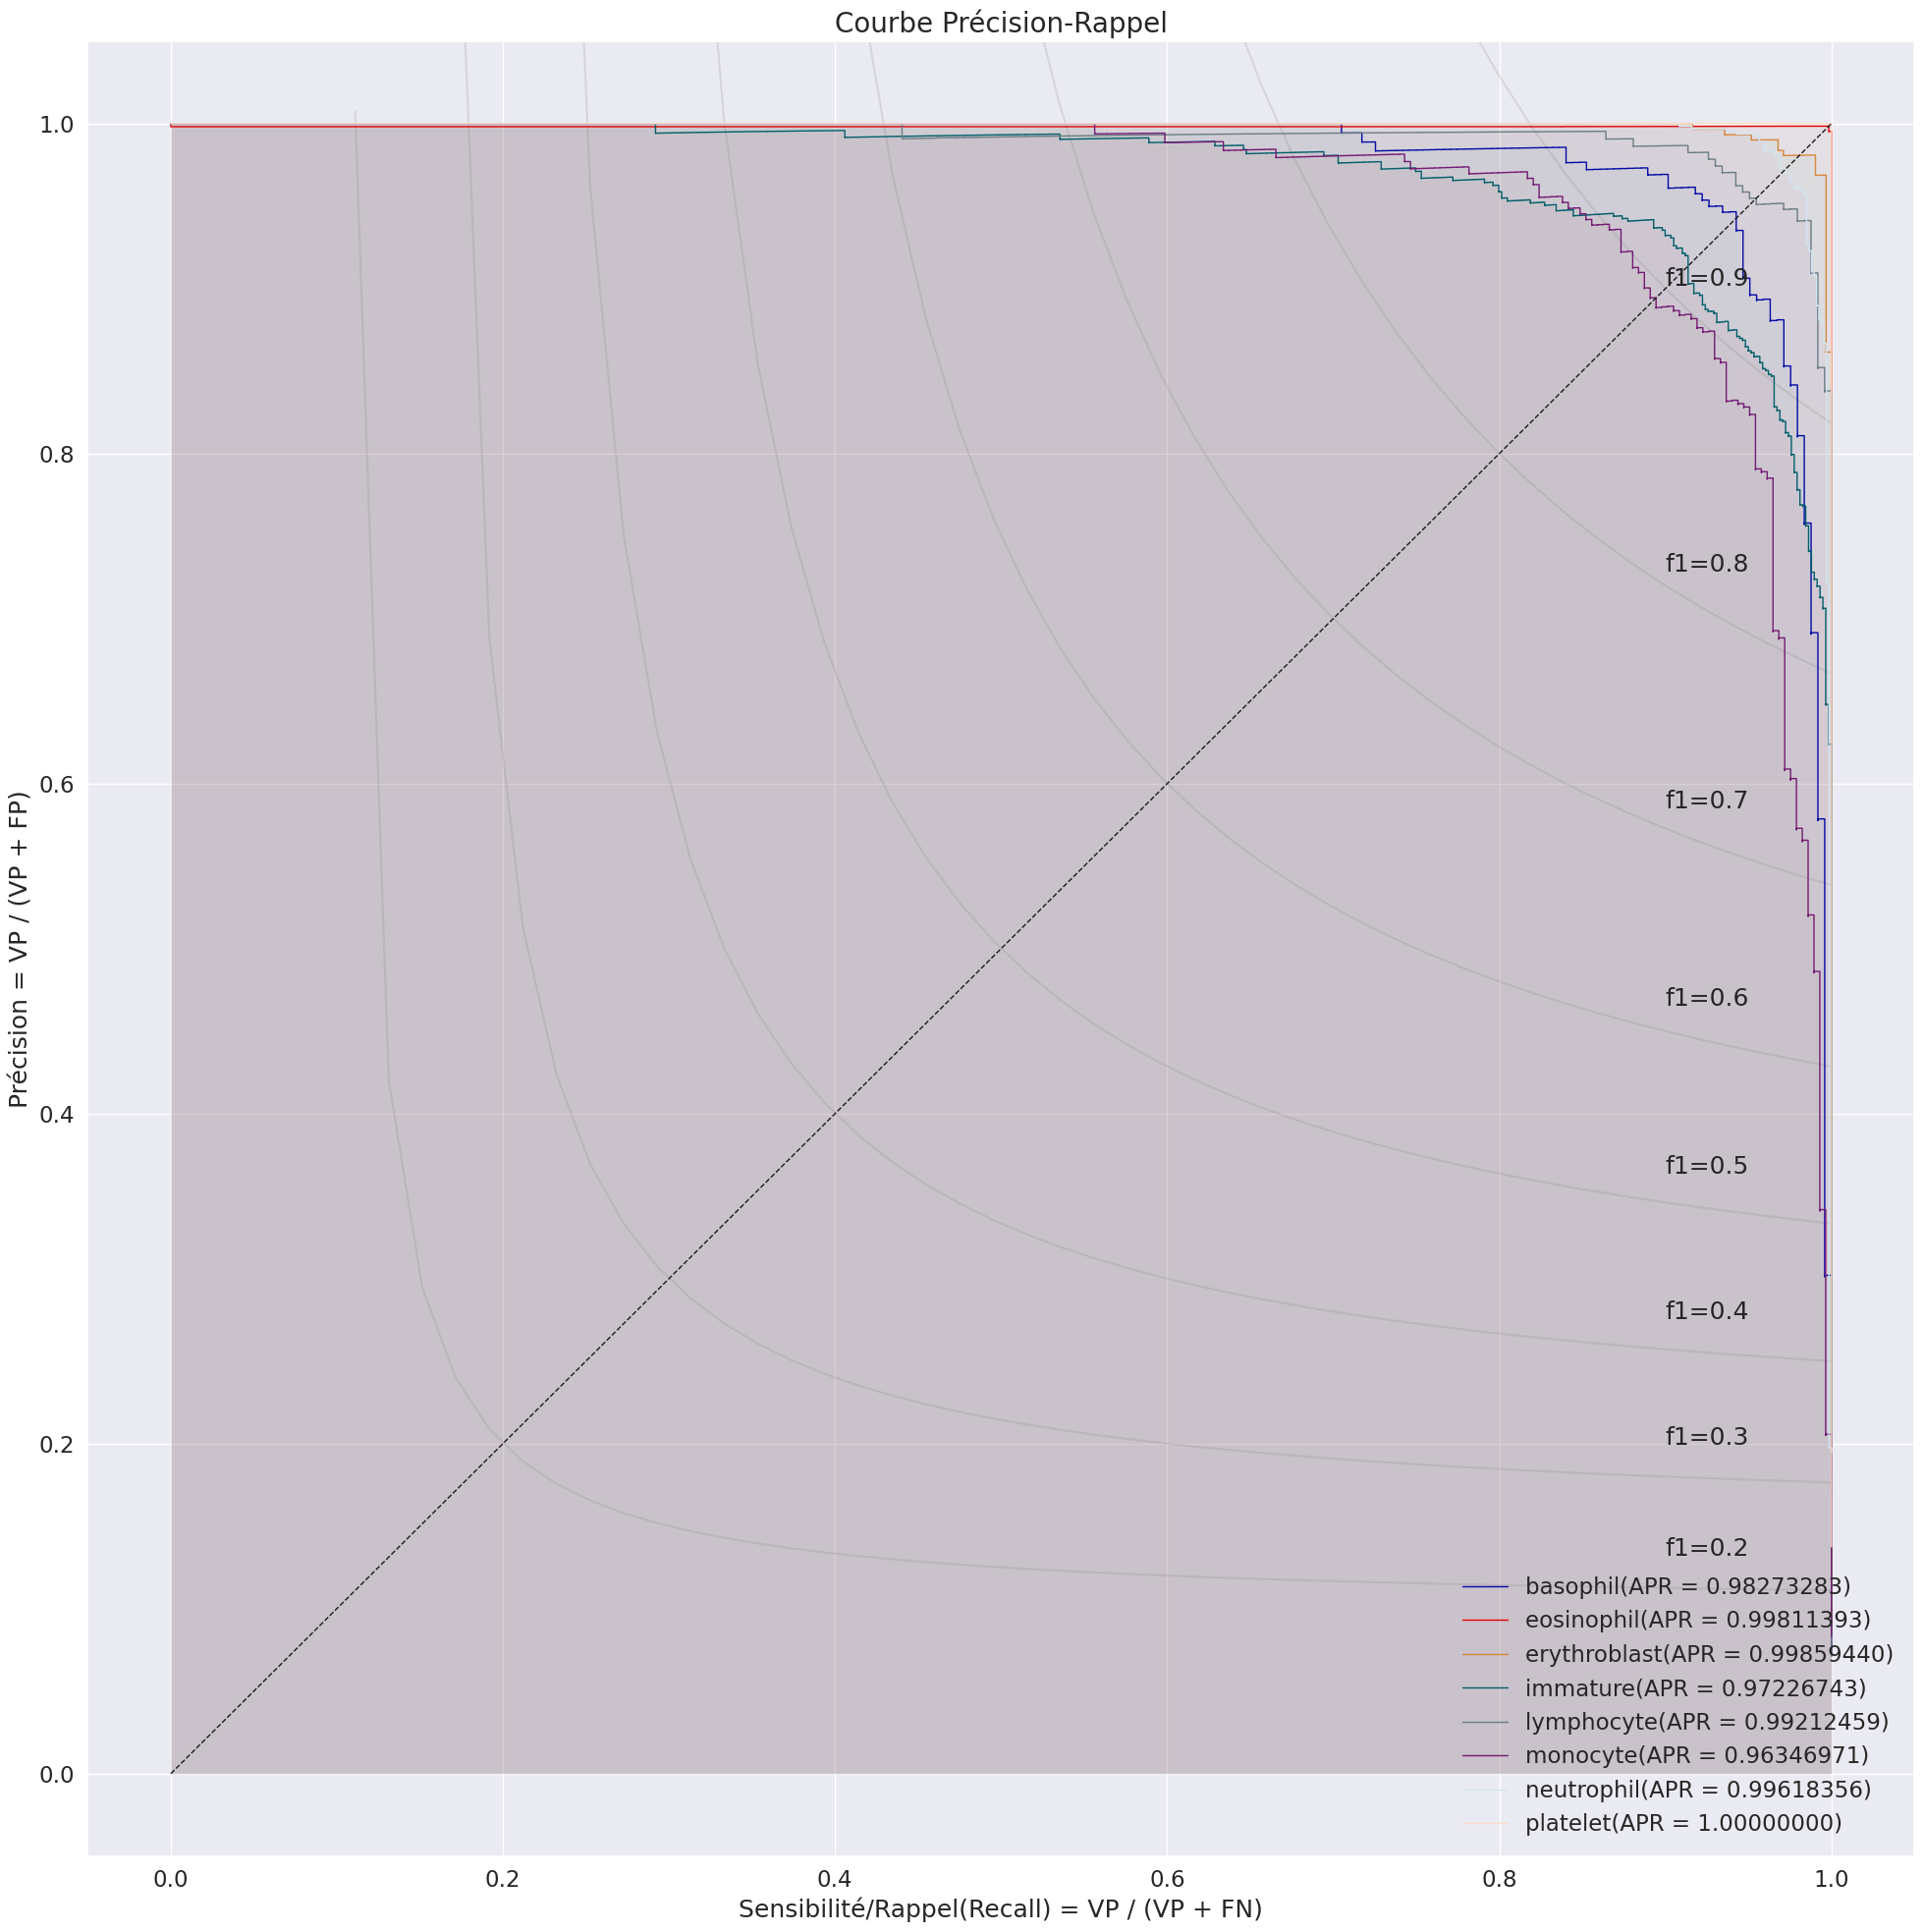

In [28]:
resultats = executeApprentissageChoixClassifieurs(
                                                  model,
                                                  X_test=images,
                                                  y_test=labels,
                                                  label_dict=dictLabels,
                                                  palette=palette, 
                                                  repertoireEnregistrement=repertoireEnregistrement,    
                                                  nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}',
                                                 );

resultats.to_parquet(os.path.join(repertoireSauvegardes,f'resultats-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.gzip'),compression='gzip', engine='pyarrow')

resultats